In [1]:
import nltk
import string
import nltk.tokenize as token
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zipf

# Choose a corpus of interest
I have choosen The Martian by Andy Weir as it is my favorite novel and I recently started reading Project Hail Mary in anticipation of watching the movie. This book is the perfect blend of tension, science and comedy so I decided I would honor is by using it for this assignment.

In [2]:
f = open("The Martian.txt", encoding='utf-8')
the_martian = f.read().replace('\n','')

# How many total unique words are in the corpus? (Please feel free to define unique words in any interesting defensible way).
In order to identify all the unique words we have to define unique words. To start I think that we should keep all conjunctions as unique words, in my opinion while these are not techinically words by definitions (grammatically at least) I think they can be representative of what people expect words to be. At least what I expect words to be, they are individual building blocks that can be use to represent unique concepts. For example, "do" and "don't" can sometimes be defined as different words depending on who you ask but most people would consider "do" and "undo" different words. While they are different words just because "don't" is a contraction shouldn't mean it isn't a unique word in this context. For that reason I am removing all punctuation except for apostrophe so that they don't get caught up in the `WhitespaceTokenizer`. (I tried using the `RegexpTokenizer` but I just have a terrible experience trying to get regex to work exactly as I need it so I decided this method, while less efficient, it does exactly what I need.) Once all the unique words are tokenized I can easily feed them into the nltk `FreqDist` to get the frequency distribution for all the tokens in the corpus. After that we can use the `B()` function to get that there are 8222 unique words in The Martian by Andy Weir.

In [3]:
punctuation = set(string.punctuation.replace("'","") + '”' + '“')

tm_sansp = the_martian.lower()
for ea in punctuation:
    tm_sansp = tm_sansp.replace(ea, '')

In [4]:
tokens = token.WhitespaceTokenizer().tokenize(tm_sansp)

In [5]:
frequency = nltk.FreqDist(tokens)
print('Total number of unique words in The Martian by Andy Weir:', frequency.B())

Total number of unique words in The Martian by Andy Weir: 8222


# Taking the most common words, how many unique words represent half of the total words in the corpus?
To determine this we have to determine how many total words are in the corpus, we can do this using the frequency distribution from before and the function `N()` which gives the total number of tokens. We divide that number in half and then to see the most common words we can sort by frequency and do a cumulative summation of the frequency to compare to the half of the total words. Once we have those rows that the cumulative sum is less than the half of total number of words we can count how many rows and get that 101 of 8222 unique words account for half the words in The Martian by Andy Weir.

In [6]:
freq_df = pd.DataFrame.from_dict(frequency, orient = 'index', columns = ['frequency'])
freq_df = freq_df.sort_values(by = 'frequency', ascending = False)

freq_df['cumulative frequency'] = freq_df['frequency'].cumsum()
freq_df['gt half'] = freq_df['cumulative frequency'] > (frequency.N()/2)

first_half = freq_df[freq_df['gt half'] == False]

print('Total number of words in The Martian by Andy Weir:                  ', 
      frequency.N())
print('Half of the total number of words in The Martian by Andy Weir:       ', 
      int(frequency.N()/2))
print('Number of unique words that represent half of all words in The Martian:', 
      len(first_half))

Total number of words in The Martian by Andy Weir:                   100752
Half of the total number of words in The Martian by Andy Weir:        50376
Number of unique words that represent half of all words in The Martian: 101


# Identify the 200 highest frequency words in this corpus.
Thankfull the `nltk.FreqDist` has a function called `most_common` where you just pass in the number of most common words you want. So we just pass in 200 and get our output easily.

In [7]:
most_common = frequency.most_common(200)
print(most_common)

[('the', 5917), ('to', 3339), ('i', 2715), ('a', 2242), ('it', 1754), ('and', 1746), ('of', 1744), ('in', 1325), ('said', 930), ('on', 803), ('for', 785), ('is', 753), ('but', 722), ('be', 691), ('that', 690), ('have', 684), ('was', 683), ('with', 670), ('my', 599), ('you', 599), ('up', 494), ('so', 479), ('he', 475), ('all', 469), ('we', 469), ('out', 458), ('as', 456), ('can', 433), ('get', 425), ('at', 403), ('from', 395), ('not', 386), ('this', 367), ('they', 367), ('time', 366), ('if', 363), ('me', 361), ('had', 332), ('rover', 325), ('just', 322), ('then', 316), ('hab', 311), ('do', 307), ('venkat', 301), ('an', 298), ('his', 298), ('them', 277), ('one', 275), ('back', 272), ("i'm", 272), ('no', 271), ('what', 268), ('need', 264), ('now', 262), ('would', 256), ("it's", 254), ('will', 242), ('it’s', 234), ('are', 229), ('how', 224), ('way', 222), ('more', 221), ('sol', 220), ('got', 216), ('when', 212), ('lewis', 210), ('about', 208), ('i’m', 202), ('right', 199), ('she', 199), ('

# Create a graph that shows the relative frequency of these 200 words.
To create a graph I simply take the values from before and put them into a `pandas` DataFrame. Then we can easily pass the words and frequencies divided by the total number of occurrences into a simple `matplotlib` bar chart.

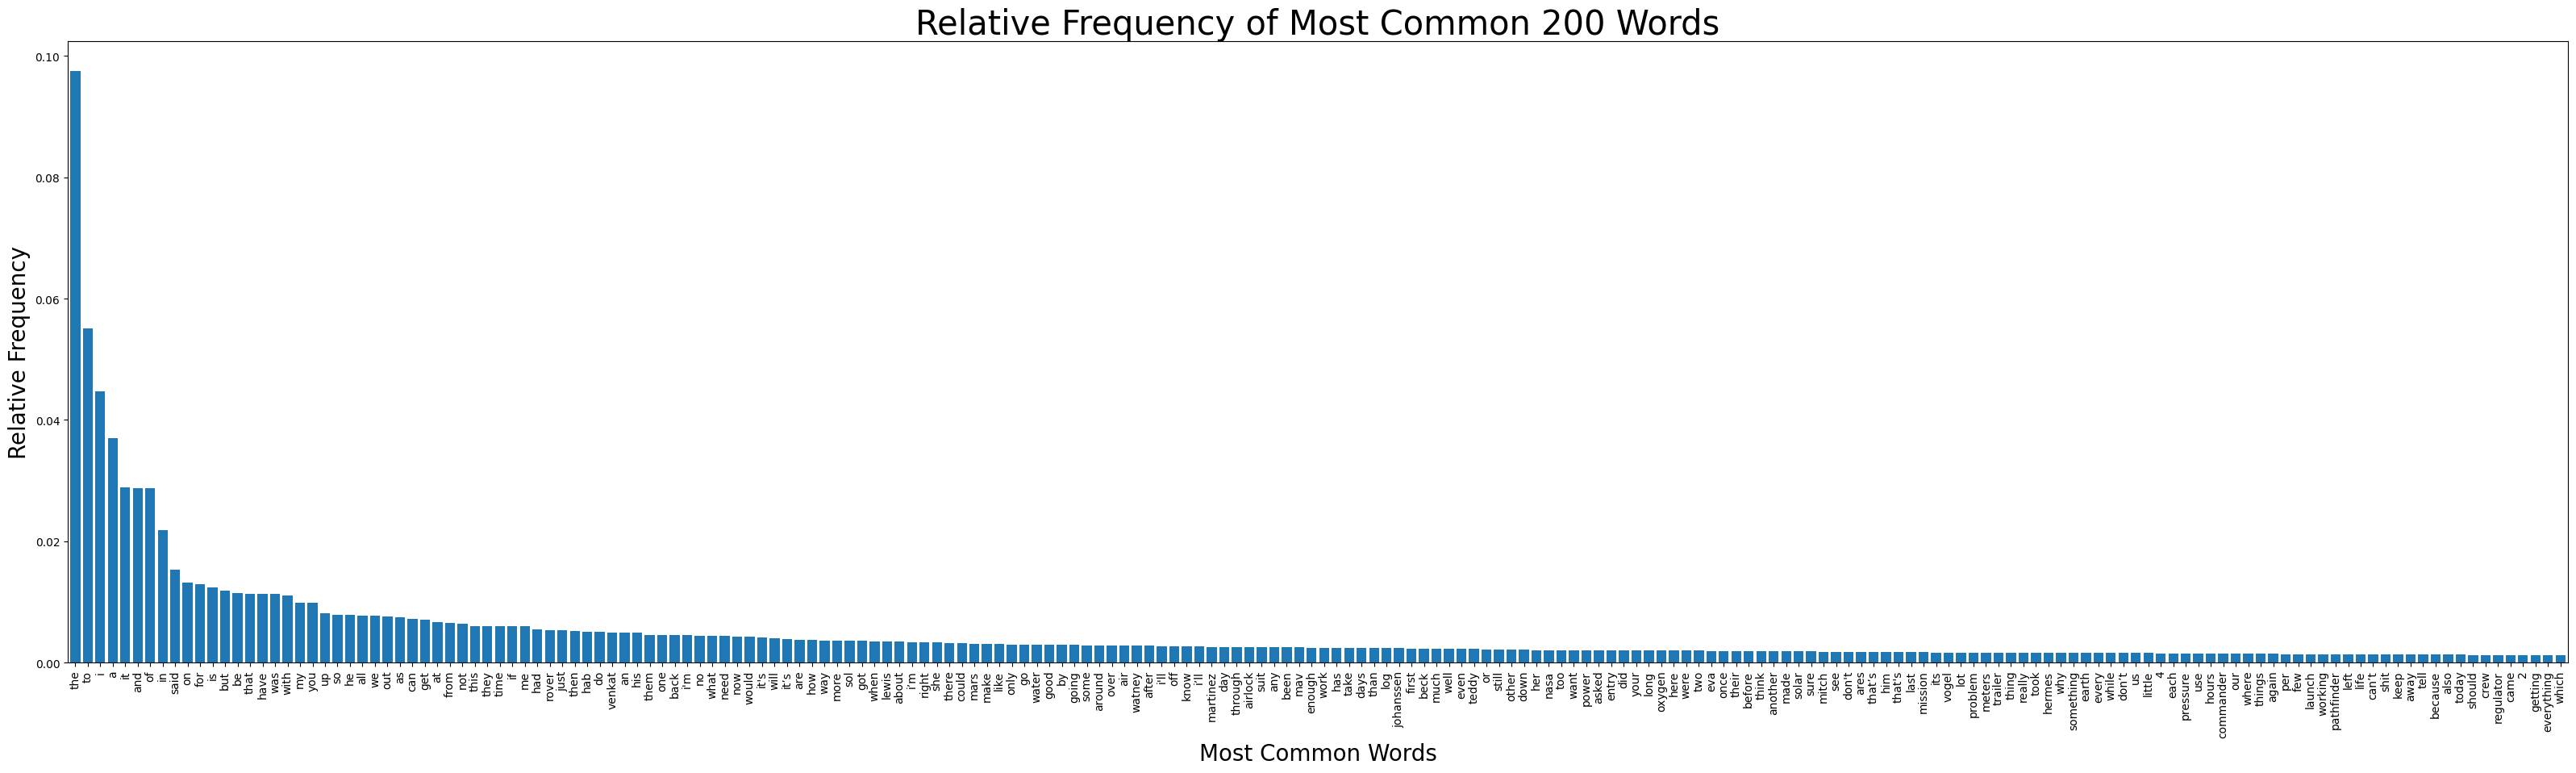

In [8]:
mc_df = pd.DataFrame(most_common, columns = ['word', 'frequency'])

# create the graph
fig, ax = plt.subplots(figsize = (40,10))
plt.title('Relative Frequency of Most Common 200 Words', size = 30)
plt.xlabel('Most Common Words', size = 20)
plt.ylabel('Relative Frequency', size = 20)
plt.xticks(rotation=90)
ax.margins(x=0.001)

plt.bar(mc_df['word'], mc_df['frequency']/sum(mc_df['frequency']), width=0.8)

plt.show()

# Does the observed relative frequency of these words follow Zipf’s law? Explain.
Using the `scipy.stats.zipf` library we can create a probability mass function to compare our output against directly. While the values don't line up exactly, you can see how by messing around with the constants I was able to get the curve to very closely line up with the first 20 or so words and then the exponential tail sits just above the actual values for the rest of the graph. In general though I would say that these frequency values would follow Zipf's law that a given word's frequency is proportional to it's rank in the frequency distribution. This is unsurprising given how often you can find Zipf's law to be true in almost all corpora.

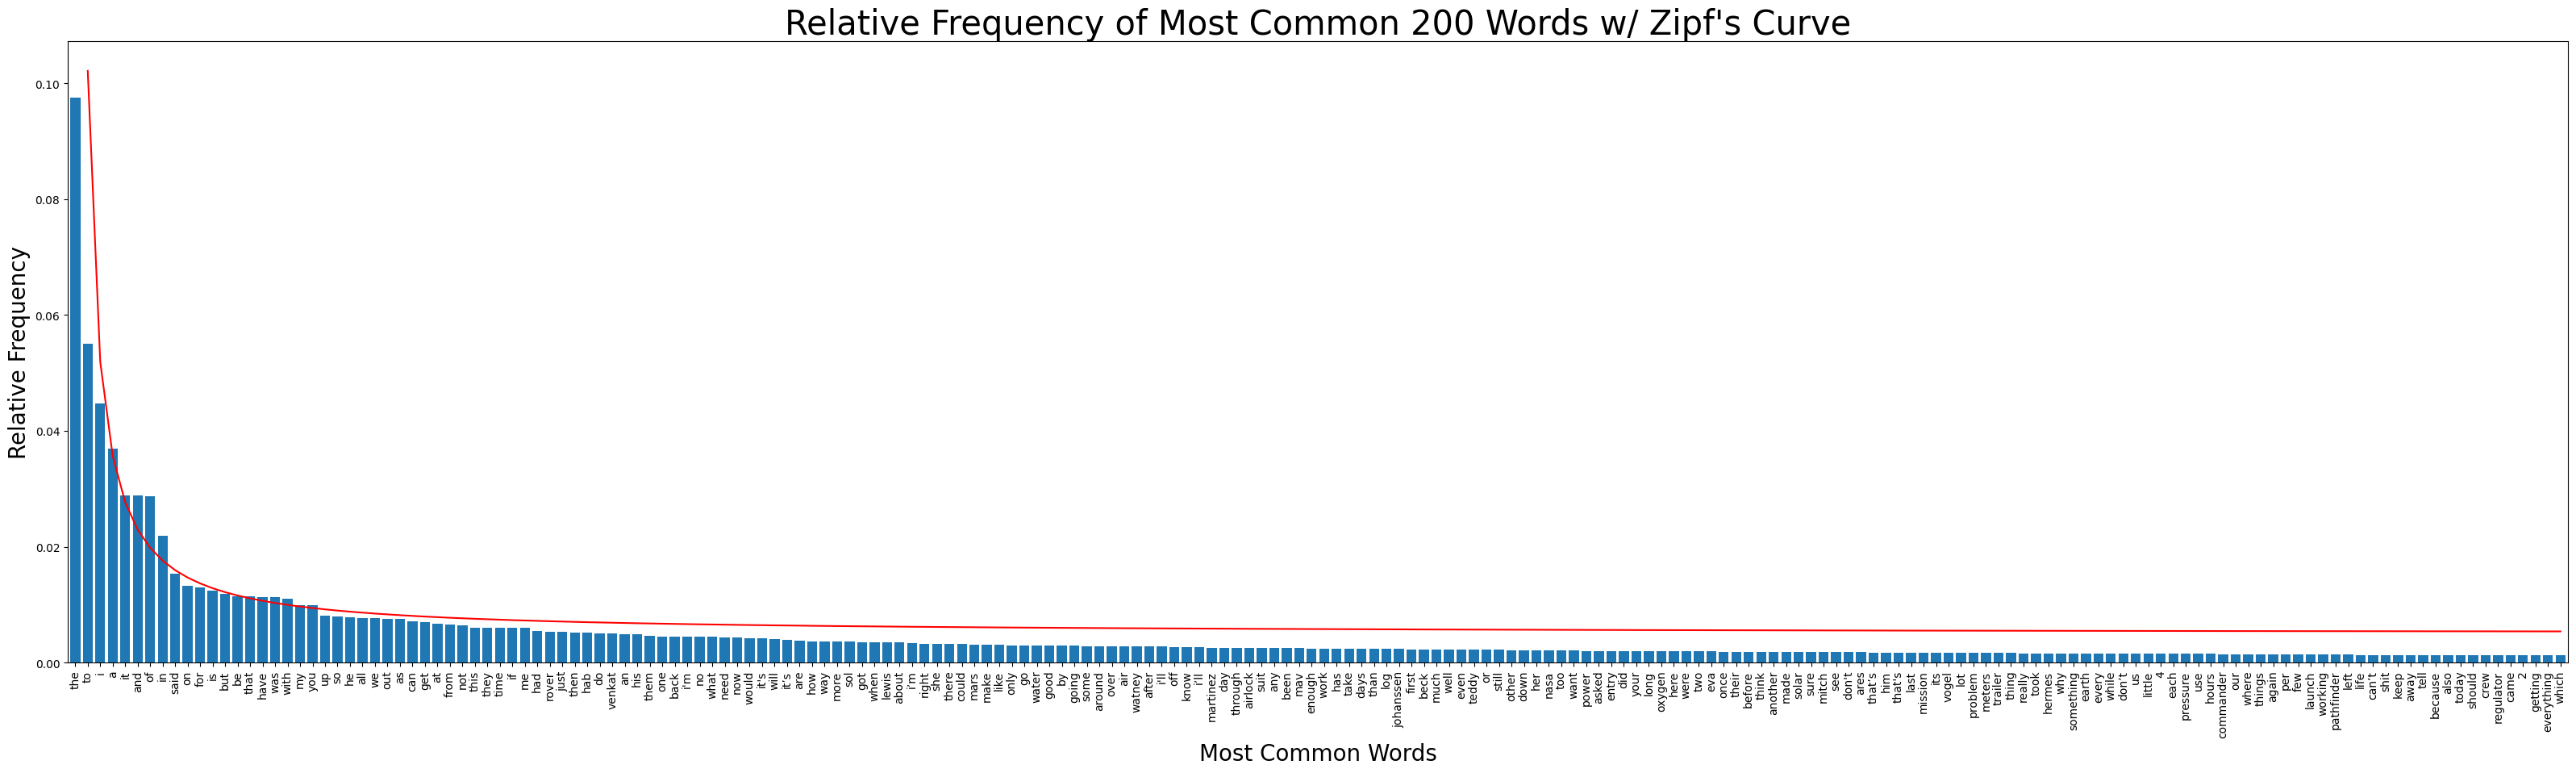

In [9]:
# probability mass function from scipy
a = 1.05
x = np.arange(1, 200)
pmf = zipf.pmf(x,a)

# create the graph
fig, ax = plt.subplots(figsize = (40,10))
plt.title('Relative Frequency of Most Common 200 Words w/ Zipf\'s Curve' , size = 30)
plt.xlabel('Most Common Words', size = 20)
plt.ylabel('Relative Frequency', size = 20)
plt.xticks(rotation=90)
ax.margins(x=0.001)

plt.bar(mc_df['word'], mc_df['frequency']/sum(mc_df['frequency']), width=0.8)
# plot the probability mass function on top of the relative frequency plot
plt.plot(x, pmf * 2 + 0.005, 'r-')

plt.show()

# In what ways do you think the frequency of the words in this corpus differ from “all words in all corpora.”
I would say that there are a number of differences. First of all this book is highly focused on it's characters and the settings for the novel. There are a lot of proper nouns that make it into the top 200, all of them names of specific characters or objects in the book like "Venkat", "Lewis", "Martinez", "Watney", "Mars", "Pathfinder", and "Hermes". A lot of other words like "rover", "sol", "hab", and "water" are extremely important to the story and thus have a high frequency of use throughout. A lot of these words are also very common and expected in the very science-y portions of the novel like "think", "power", "oxygen", and "pressure". In general, since this is a science fiction book I would expect there to be a higher frequency of terms used in those contexts than would be expected in "all words in all corpora" which will have a lot more general parts of speech.